# Stable softmax

**Insight:** softmax is invariant to shifting all logits. Subtract `max(z)` before `exp` so large values do not overflow.

$$\mathrm{softmax}(z)_i = \frac{e^{z_i - \max z}}{\sum_j e^{z_j - \max z}}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    z = np.asarray(z, dtype=np.float64)
    z = z - np.max(z)
    e = np.exp(z)
    return e / e.sum()

def naive_softmax(z):
    e = np.exp(np.asarray(z, dtype=np.float64))
    return e / e.sum()


## Small logits — both fine

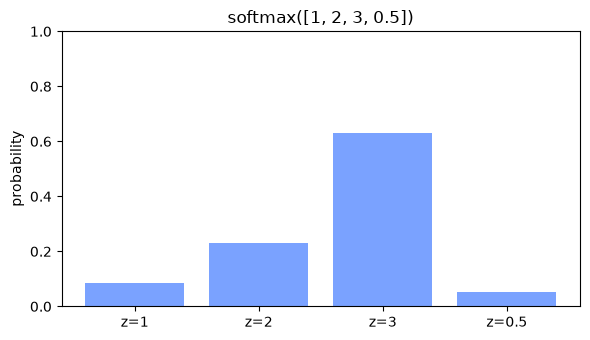

sum = 1.0


In [2]:
z = np.array([1.0, 2.0, 3.0, 0.5])
p = softmax(z)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(len(z)), p, color='#7aa2ff')
ax.set_xticks(range(len(z)))
ax.set_xticklabels([f'z={v:g}' for v in z])
ax.set_ylabel('probability')
ax.set_title('softmax([1, 2, 3, 0.5])')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print('sum =', p.sum())


## Large logits — naive overflows, stable does not

stable: [0.09003057 0.24472847 0.66524096] finite True
naive ok: False


/tmp/ipykernel_283457/2979464594.py:11: RuntimeWarning: overflow encountered in exp
  e = np.exp(np.asarray(z, dtype=np.float64))
/tmp/ipykernel_283457/2979464594.py:12: RuntimeWarning: invalid value encountered in divide
  return e / e.sum()


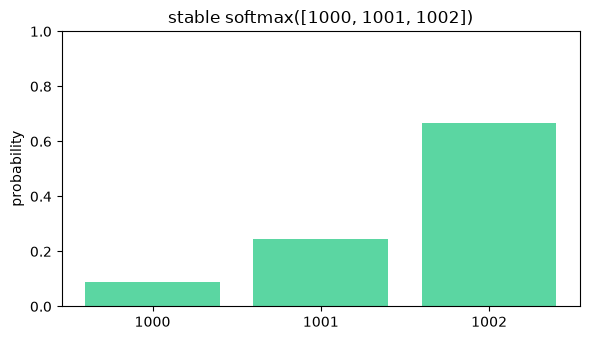

In [3]:
big = np.array([1000.0, 1001.0, 1002.0])
stable = softmax(big)
try:
    naive = naive_softmax(big)
    naive_ok = np.isfinite(naive).all()
except Exception:
    naive = None
    naive_ok = False

print('stable:', stable, 'finite', np.isfinite(stable).all())
print('naive ok:', naive_ok)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(len(big)), stable, color='#5bd6a2')
ax.set_xticks(range(len(big)))
ax.set_xticklabels([str(int(v)) for v in big])
ax.set_ylabel('probability')
ax.set_title('stable softmax([1000, 1001, 1002])')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
